# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Throwing in a penalty keeps the model from blowing up the coefficients just to squeeze out a little more training accuracy. It nudges things toward simpler, more stable solutions that don't end up chasing noise in the data.
2. The penalty strength is basically a knob for tuning model complexity. A small penalty means low bias but higher variance, while a large penalty shrinks the coefficients more, which typically bumps up bias but cuts variance. Adjusting the penalty is really just moving along the bias-variance trade-off.
3. The main difference is the type of penalty. Ridge uses L2, which pulls coefficients toward zero but usually doesn't zero them out completely. LASSO uses L1, which can shrink some coefficients all the way to zero, so it ends up doing variable selection at the same time. In practice, Ridge keeps all the predictors around with smaller weights, while LASSO gives you a sparser model.
4. Before fitting, you usually want to standardize the predictors by subtracting the mean and dividing by the standard deviation. This matters because the penalty acts on coefficient size, so predictors on bigger scales would get penalized unfairly more or less than the others. Scaling puts everything on the same footing so the penalty hits each variable comparably.
5. Picking the penalty alpha usually comes down to cross-validation. You fit the model across a grid of alpha values and go with whichever one gives the best out-of-sample performance, typically the lowest cross-validated MSE.
6. No, cross-validated MSE is usually based on prediction error on the validation fold, not the penalized objective. The whole point of cross-validation is to see how well the model predicts new data, and future prediction error doesn't have a penalty term baked in. The penalty is really a training tool, not something we actually care about at evaluation time.
7. When people say regularization "shrinks" coefficients, they mean it pulls the estimates closer to zero than what OLS would give you. Smaller coefficients make the model less reactive to random quirks in the training sample, so predictions stay more consistent across different samples and variance drops.
8. Because the penalty is applied directly to coefficient size, standardizing matters a lot. If one predictor is on a much larger scale than another, its coefficient ends up looking smaller just by default, and the penalty treats the variables unevenly. Putting everything on a common scale keeps the penalty fair across predictors.
9. Typically the intercept gets left alone because it's just shifting the overall prediction level up or down, not controlling how complex the relationship between predictors and outcome is. Penalizing it would mostly just distort the fit without really helping with overfitting.
10. As alpha → 0, you basically get the ordinary least squares solution back. As alpha gets really large, the coefficients get pushed hard toward zero. With Ridge they end up very small, and with LASSO a lot of them can go all the way to zero.
11. Test performance can actually improve with regularization because you're trading a bit of extra bias for a potentially big drop in variance. The training fit might look a little worse, but the model tends to generalize better since it isn't chasing noise in the sample.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [16]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV, lasso_path, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/cars_hw.csv')

df['Age'] = np.max(df['Make_Year']) - df['Make_Year']
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,5
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,6
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,3
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,5
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,5


1.

In [17]:
target = df['Price']
features = df[['Mileage_Run', 'Age']]

poly_transformer = PolynomialFeatures(degree=3, include_bias=False)
features_expanded = poly_transformer.fit_transform(features)
poly_names = poly_transformer.get_feature_names_out(features.columns)

features_scaled = StandardScaler().fit_transform(features_expanded)

2.

In [18]:
linear_model = LinearRegression().fit(features_scaled, target)
linear_coefs = linear_model.coef_

3.

In [19]:
alpha_grid = np.logspace(1, 3, 30)

lasso_model = LassoCV(alphas=alpha_grid, cv=20, max_iter=10000).fit(features_scaled, target)

4.

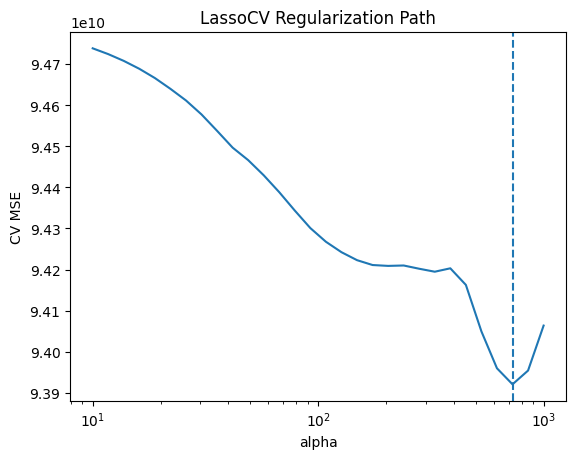

In [20]:
avg_cv_mse = lasso_model.mse_path_.mean(axis=1)

fig, ax = plt.subplots()
ax.plot(lasso_model.alphas_, avg_cv_mse)
ax.axvline(lasso_model.alpha_, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("CV MSE")
ax.set_title("LassoCV Regularization Path")
plt.show()

5.

/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.166e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.351e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

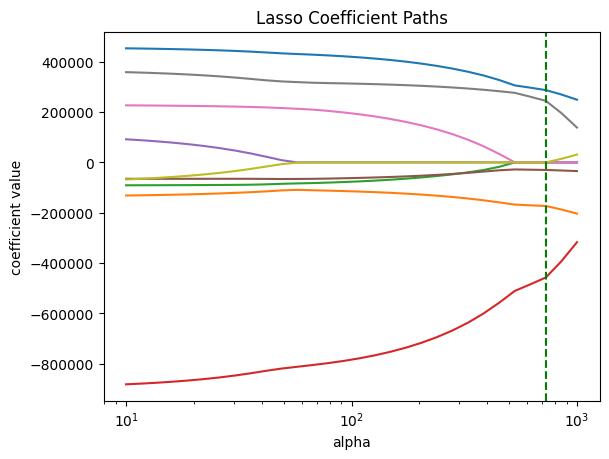

In [21]:
path_alphas, path_coefs, _ = lasso_path(features_scaled, target, alphas=alpha_grid)

fig, ax = plt.subplots()
for c in path_coefs:
    ax.plot(path_alphas, c)
ax.axvline(x=lasso_model.alpha_, color='green', linestyle='--')
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("coefficient value")
ax.set_title("Lasso Coefficient Paths")
plt.show()

5.

In [22]:
nonzero_idx = np.flatnonzero(lasso_model.coef_)
print(nonzero_idx)
print(poly_names[nonzero_idx])
print(f'Proportion of variables selected: {len(nonzero_idx)/len(poly_names)}')

pd.DataFrame({
    'feature': poly_names,
    'linear_model': linear_coefs,
    'lasso': lasso_model.coef_
})

[0 1 3 5 7]
['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Mileage_Run Age^2']
Proportion of variables selected: 0.5555555555555556


,feature,linear_model,lasso
0,Mileage_Run,458071.119627,288335.957408
1,Age,-136698.072100,-172564.545030
2,Mileage_Run^2,-91643.120024,-0.000000
3,Mileage_Run Age,-898405.751356,-460528.046246
4,Age^2,113603.822348,-0.000000
5,Mileage_Run^3,-65144.896599,-29689.554572
6,Mileage_Run^2 Age,229021.676556,0.000000
7,Mileage_Run Age^2,368955.713359,246310.472510
8,Age^3,-84038.066146,0.000000


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [23]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV, lasso_path, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

1.

In [24]:
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
cat_poly_transformer = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
cat_expanded = cat_poly_transformer.fit_transform(df[cat_vars])
cat_names = cat_poly_transformer.get_feature_names_out(cat_vars)

num_vars = ['age', 'ejection_fraction', 'serum_creatinine']
num_poly_transformer = PolynomialFeatures(degree=3, include_bias=False)
num_expanded = num_poly_transformer.fit_transform(df[num_vars])
num_names = num_poly_transformer.get_feature_names_out(num_vars)
num_scaled = StandardScaler().fit_transform(num_expanded)

X = np.concatenate([cat_expanded, num_scaled], axis=1)
names = np.concatenate([cat_names, num_names])
y = df['DEATH_EVENT']

2.

In [25]:
linear_model = LinearRegression().fit(X, y)
ols_coef = linear_model.coef_

3.

In [26]:
alpha_grid = np.logspace(-5, 5, 30)

lasso_model = LassoCV(alphas=alpha_grid, cv=20, max_iter=10000).fit(X, y)

/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.661e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.488e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

4.

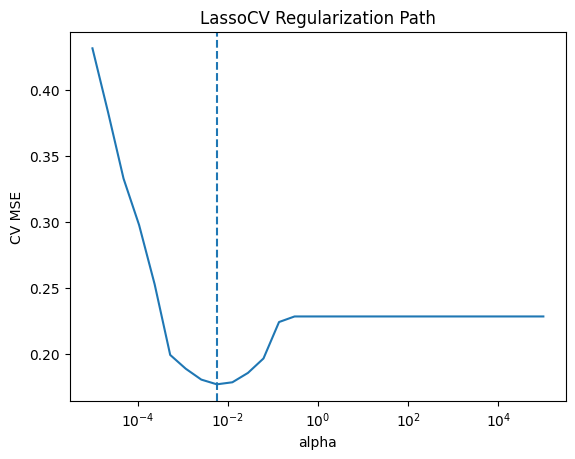

In [27]:
avg_cv_mse = lasso_model.mse_path_.mean(axis=1)

fig, ax = plt.subplots()
ax.plot(lasso_model.alphas_, avg_cv_mse)
ax.axvline(lasso_model.alpha_, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("CV MSE")
ax.set_title("LassoCV Regularization Path")
plt.show()

5.

/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.349e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.217e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/haydenwillen/Desktop/DS3021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

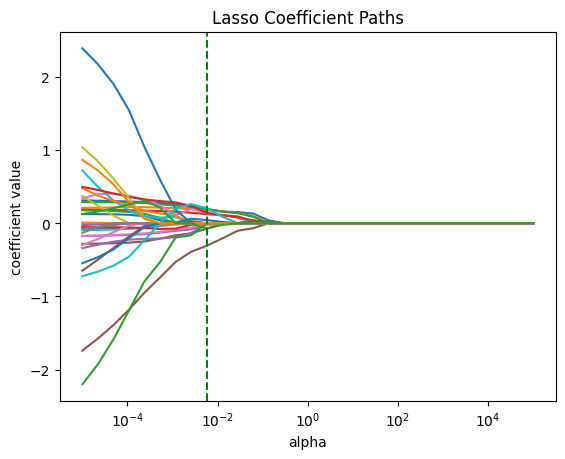

In [28]:
path_alphas, path_coefs, _ = lasso_path(X, y, alphas=alpha_grid)

fig, ax = plt.subplots()
for c in path_coefs:
    ax.plot(path_alphas, c)
ax.axvline(x=lasso_model.alpha_, color='green', linestyle='--')
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("coefficient value")
ax.set_title("Lasso Coefficient Paths")
plt.show()

6.

In [29]:
nonzero_idx = np.flatnonzero(lasso_model.coef_)
print(nonzero_idx)
print(names[nonzero_idx])
print(f'Proportion of variables selected: {len(nonzero_idx)/len(names)}')

pd.DataFrame({
    'feature': names,
    'linear_model': ols_coef,
    'lasso': lasso_model.coef_
})

[ 0  1  2  7  8  9 15 16 23 29 30 32]
['anaemia' 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking' 'ejection_fraction'
 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3']
Proportion of variables selected: 0.36363636363636365


,feature,linear_model,lasso
0,anaemia,-0.043420,0.014177
1,diabetes,-0.149472,0.000609
2,high_blood_pressure,-0.073480,0.013609
3,smoking,-0.168209,-0.000000
4,anaemia diabetes,0.137585,0.000000
5,anaemia high_blood_pressure,0.040708,0.000000
6,anaemia smoking,0.139289,0.000000
7,diabetes high_blood_pressure,0.282831,0.053965
8,diabetes smoking,0.337922,0.003466
9,high_blood_pressure smoking,0.213817,0.017803


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. The objective function becomes

$$\frac{1}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha b_1^2.$$

2. The first order conditions are

$$\frac{-2}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i) = 0$$

$$\frac{-2}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i)\tilde{x}_i + 2\alpha b_1 = 0$$

The first equation implies that $b_0^* = 0$, since

$$\frac{1}{n}\sum_{i=1}^{n}\tilde{y}_i - nb_0 - b_1\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i = 0$$

implies $\hat{b}_0 = 0$. Solving the second equation using that $\hat{b}_0 = 0$, the second equation implies that

$$\hat{b}_1 = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2 + \alpha}.$$

3. As $\alpha$ goes up, the slope coefficient shrinks (this is why regularization is also called "shrinkage").

4. This is a lot harder. The CHALLENGE is that $|x|$ is not differentiable at zero, so the "derivative" of $|x|$ is

$$|x|' = \begin{cases} -1, & x < 0 \\ \text{undefined}, & x = 0 \\ +1, & x > 0. \end{cases}$$

This makes solving the equations much more difficult. That's a totally sufficient answer.

For a bit more detail, we can follow the same steps as for Ridge, which yield a slope coefficient of

$$\hat{b}_1 = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}) - \frac{\alpha}{2}|\hat{b}_1|'}{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}.$$

But it's a conceptual challenge to make sense of this, because $|b_1|'$ depends on $\hat{b}_1$. If this expression:

$$\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}) - \frac{\alpha}{2}}{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

is strictly positive, then it can be $\hat{b}_1$ without contradiction and we are done; similarly, if this expression

$$\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}) + \frac{\alpha}{2}}{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

is strictly negative, then it can be $\hat{b}_1$ without contradiction and we are done. However, if the sign of $\hat{b}_1$ keeps "flipping back and forth" because $|\hat{b}_1|'$ is jumping back and forth from -1 to +1, then we can't solve for $\hat{b}_1$. In that case, we reach a contradiction, and the solution is then to set $\hat{b}_1 = 0$. This is how the coefficients get "zeroed out" in the LASSO, typically using a technique called LARS (Least Angle Regression).